In [3]:
import pygad
import numpy as np
import win32com.client
import pandas as pd
import time
import matplotlib.pyplot as plt
import warnings
from deap import base, creator, tools, algorithms
# Suppress all warnings
warnings.filterwarnings("ignore")

In [2]:
import pygad

In [40]:

# Connect to Vissim
Vissim = win32com.client.Dispatch("Vissim.Vissim")

# Load the Vissim network
# filename = r"C:\Users\ets\ORNL Dropbox\Abhilasha Saroj\VSI_Projects\Projects Folder\CC_RealTwin\Preliminary Calibration\VISSIM_Calibration\shallowford_res1\shallowford_mod_v13_ACS_cal.inpx"
filename = r"C:\Users\ets\ORNL Dropbox\Abhilasha Saroj\VSI_Projects\Projects Folder\CC_RealTwin\Preliminary Calibration\VISSIM_Calibration\shallowford\shallowford_mod_v13_ACS_cal.inpx"

Vissim.LoadNet(filename)


In [9]:
# For each intersectionin gridsmart get EB, WB, NB, SB totals for the time - Get Observed Data for all Locations From Gridsmart - intid_total
df_gridsmart_demand =  pd.read_csv("C:\\Users\\ets\\Desktop\\Projects\\RT_ScenarioGenerator\\GridSmart_demand.csv")
# unique_intersections = df_gridsmart_demand['IntersectionName'].unique().tolist()
# print (unique_intersections)

def get_approach_observed_counts_dictionary_available_intersections(df, start_time, end_time):
    unique_intersections = df['IntersectionName'].unique().tolist()
    # print (unique_intersections)
    unique_intersections.pop()


    my_dict = {}

    for i in range(len(unique_intersections)):
        # Filter the DataFrame for the specific intersection
        intersection_df = df[df['IntersectionName'] == unique_intersections[i]]

        # Convert 'Time' column to datetime for proper comparison
        intersection_df['Time'] = pd.to_datetime(intersection_df['Time'], format='%H:%M')

        # Convert start_time and end_time to datetime
        start = pd.to_datetime(start_time, format='%H:%M')
        end = pd.to_datetime(end_time, format='%H:%M')

        # print ("HERE")

        # Filter rows within the specified time interval
        mask = (intersection_df['Time'] >= start) & (intersection_df['Time'] <= end)
        filtered_df = intersection_df.loc[mask]

        # Calculate the sum of NB volumes within the interval
        nb_volume = filtered_df[['NBR', 'NBT', 'NBL', 'NBU']].sum().sum()
        sb_volume = filtered_df[['SBR', 'SBT', 'SBL', 'SBU']].sum().sum()
        eb_volume = filtered_df[['EBR', 'EBT', 'EBL', 'EBU']].sum().sum()
        wb_volume = filtered_df[['WBR', 'WBT', 'WBL', 'WBU']].sum().sum()

        # Sum the NB totals for the specific intersection

        my_dict[unique_intersections[i]]= [eb_volume, wb_volume, sb_volume, nb_volume]
    # print (my_dict)
    return my_dict

    # return [NB_approach_totals, SB_approach_totals, EB_approach_totals, WB_approach_totals]

In [10]:
get_approach_observed_counts_dictionary_available_intersections(df_gridsmart_demand, '8:00','8:45' )

{'Amin Dr./Shallowford Village Dr. & Shallowford Rd.': [531.0,
  929.0,
  122.0,
  43.0],
 'Shallowford Rd. & I-75 SB Off Ramp': [546.0, 1037.0, 693.0, 0.0],
 'Hamilton Place Blvd./Napier Dr. & Shallowford Rd.': [973.0,
  1002.0,
  22.0,
  167.0],
 'Lifestyle Way & Shallowford Rd.': [1108.0, 1079.0, 107.0, 49.0],
 'Gunbarrel Road & Shallowford Rd.': [1072.0, 785.0, 363.0, 417.0],
 'I-75 NB Off Ramp & Shallowford Rd.': [918.0, 1062.0, 0.0, 765.0]}

In [11]:
## Add new driveway observation placeholders 
def get_approach_observed_counts_dictionary_unavailable_intersections(unique_unsignalized_intersections):
    driveway_observed_dict = {}
    for i in range(len(unique_unsignalized_intersections)):
        driveway_observed_dict[unique_unsignalized_intersections[i]]= 0
    return driveway_observed_dict



In [13]:
unique_unsignalized_intersections = ["D1", "D2", "D3", "D4"]
unique_intersections = df_gridsmart_demand['IntersectionName'].unique().tolist()
unique_intersections.pop()
print (unique_intersections)

['Amin Dr./Shallowford Village Dr. & Shallowford Rd.', 'Shallowford Rd. & I-75 SB Off Ramp', 'Hamilton Place Blvd./Napier Dr. & Shallowford Rd.', 'Lifestyle Way & Shallowford Rd.', 'Gunbarrel Road & Shallowford Rd.', 'I-75 NB Off Ramp & Shallowford Rd.']


In [14]:
# Observed count data collection counter dictionary
observed_set1 = get_approach_observed_counts_dictionary_available_intersections(df_gridsmart_demand, '8:00', '8:45')
observed_set2 = get_approach_observed_counts_dictionary_unavailable_intersections(unique_unsignalized_intersections)
all_intersections_observed_count_dict  = observed_set1.copy()
all_intersections_observed_count_dict .update(observed_set2)

# print (all_intersections_observed_count_dict)

all_intersections_name = unique_intersections+ unique_unsignalized_intersections
# print (all_intersections_name)


In [31]:

# # Define the GEH function
# def calculate_geh(observed, simulated):
#     if observed + simulated == 0:
#         return 0
#     return np.sqrt(2 * ((observed - simulated) ** 2) / (observed + simulated))

In [15]:
def createVehicleInputs(veh_input_link_list_final):
    vissim_veh_input_keys_list = []
    for i in range(len(veh_input_link_list_final)):
        # if veh_input_link_list_final[i] == 32:
        #     veh_input_vissim_link = 31
        # else:
        veh_input_vissim_link = veh_input_link_list_final[i]
        vissim_link_object = Vissim.Net.Links.ItemByKey(veh_input_vissim_link)
        VehInput = Vissim.Net.VehicleInputs.AddVehicleInput(0, vissim_link_object)
        print (VehInput.AttValue('No'))
        vissim_veh_input_keys_list.append(VehInput.AttValue('No'))
    return vissim_veh_input_keys_list

In [36]:
# DO ONLY ONCE: create new vehicle inputs for the new vehicle input links -  Friday
# cal_veh_input_vissim_link_list = [52, 41, 37, 51]
# createVehicleInputs(cal_veh_input_vissim_link_list)



13
14
15
16


[13, 14, 15, 16]

In [16]:
#vissim function set a route at a position for a vissim road id 
def set_route(route_no, vissim_start_link_no, vissim_dest_link_list, route_flow_ratio_list, interval_number):
    vissim_start_link = Vissim.Net.Links.ItemByKey(vissim_start_link_no)
    if interval_number==1:
        VehRoutDesSta = Vissim.Net.VehicleRoutingDecisionsStatic.AddVehicleRoutingDecisionStatic(route_no, vissim_start_link, 5)
        for i in range(len(vissim_dest_link_list)):
            vissim_end_link = Vissim.Net.Links.ItemByKey(vissim_dest_link_list[i])
            VehRoutSta = VehRoutDesSta.VehRoutSta.AddVehicleRouteStatic(i+1, vissim_end_link, 4)
            VehRoutSta.SetAttValue("RelFlow("+str(interval_number)+")", route_flow_ratio_list[i])
    else:
        VehRoutSta = Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no)
        for i in range(len(vissim_dest_link_list)):
            Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no).VehRoutSta.ItemByKey(i+1).SetAttValue("RelFlow("+str(interval_number)+")", route_flow_ratio_list[i])
            # VehRoutSta.SetAttValue("RelFlow("+str(interval_number)+")", route_flow_ratio_list[i])


In [ ]:
static_routing_decisions = Vissim.Net.VehicleRoutingDecisionsStatic.GetAll()

# Count the number of static routing decisions
count_static_routing_decisions = len(static_routing_decisions)
print (count_static_routing_decisions)


24


In [17]:
## Calculate turn ratios for new routes and impacted routes

# initial_solution = [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.5, 0.5, 0.5, 0.5]
# initial_solution[0] = 0.2
## Impacted Routes
def calc_turns_napierEB(initial_solution):
## Between Napier Rd. and Lifestyle Way1 and Way 2 - EASTBOUND
    interval_routes_napierEB_final_RTL=[[0.028674, 0.853047, 0.11828], [0.031873, 0.856574, 0.111554], [0.044444, 0.855556, 0.1], [0.035714, 0.88961, 0.074675]]
    first_right = initial_solution[0]
    second_right = (1-initial_solution[0])*initial_solution[1]
    rest = 1 - (first_right+second_right)
    # print (rest)

    interval_new_turns = []
    for i in range(len(interval_routes_napierEB_final_RTL)):
        final_right_eb = rest*interval_routes_napierEB_final_RTL[i][0]
        # print (final_right)
        final_thru_eb = rest*interval_routes_napierEB_final_RTL[i][1]
        final_left_eb = rest*interval_routes_napierEB_final_RTL[i][2]
        interval_new_turns.append([final_right_eb, final_thru_eb, final_left_eb, 0, first_right, second_right])
    
    return interval_new_turns


def calc_turns_napierWB(initial_solution):
    ## Between Napier Rd. and Lifestyle Way1 and Way 2 - WESTBOUND
    interval_routes_napierWB_final_RTL=[[0, 0.919492, 0.080508], [0, 0.935606, 0.064394], [0.003745, 0.902622, 0.093633], [0.004255, 0.931915, 0.06383]]
    first_left = initial_solution[2]
    second_left = (1-initial_solution[2])*initial_solution[3]
    rest_napier_WB = 1 - (first_left+second_left)
    # print (rest_napier_WB)

    interval_new_turns = []
    for i in range(len(interval_routes_napierWB_final_RTL)):
        final_right_wb = rest_napier_WB*interval_routes_napierWB_final_RTL[i][0]
        # print (final_right)
        final_thru_wb = rest_napier_WB*interval_routes_napierWB_final_RTL[i][1]
        final_left_wb = rest_napier_WB*interval_routes_napierWB_final_RTL[i][2]
        # print (first_left, second_left, final_right_wb, final_thru_wb, final_left_wb)
        interval_new_turns.append([final_right_wb, final_thru_wb, final_left_wb, 0, second_left, first_left])
    
    return interval_new_turns

In [70]:
p= calc_turns_napierEB()
print (p)
q = calc_turns_napierWB()
print (q)

0.6399999999999999
[[0.2, 0.16000000000000003, 0.018351359999999997, 0.5459500799999999, 0.07569919999999998], [0.2, 0.16000000000000003, 0.020398719999999995, 0.5482073599999999, 0.07139456], [0.2, 0.16000000000000003, 0.028444159999999993, 0.5475558399999999, 0.06399999999999999], [0.2, 0.16000000000000003, 0.02285696, 0.5693503999999999, 0.047791999999999994]]
0.6399999999999999
[[0.2, 0.16000000000000003, 0.0, 0.5884748799999999, 0.05152511999999999], [0.2, 0.16000000000000003, 0.0, 0.59878784, 0.04121216], [0.2, 0.16000000000000003, 0.0023967999999999997, 0.57767808, 0.059925119999999985], [0.2, 0.16000000000000003, 0.0027232, 0.5964255999999999, 0.04085119999999999]]


In [18]:
## Calculate turn between LIfestyle and Gunbarrel 
def calc_turns_lifestyleEB(initial_solution):
    interval_routes_LifestyleEB_final_RTL=[[0.429078, 0.468085, 0.102837], [0.408088, 0.533088, 0.058824], [0.449541, 0.43578, 0.114679], [0.42, 0.47, 0.11]]
    first_left = initial_solution[4]
    rest_napier_EB= 1 - (first_left)
    # print (rest_napier_EB)

    interval_new_turns = []
    for i in range(len(interval_routes_LifestyleEB_final_RTL)):
        final_right_eb = rest_napier_EB*interval_routes_LifestyleEB_final_RTL[i][0]
        # print (final_right)
        final_thru_eb = rest_napier_EB*interval_routes_LifestyleEB_final_RTL[i][1]
        final_left_eb = rest_napier_EB*interval_routes_LifestyleEB_final_RTL[i][2]
        interval_new_turns.append([final_right_eb, final_thru_eb, final_left_eb, 0, first_left])
        # print (first_right, final_right_eb, final_thru_eb, final_left_eb)
    return interval_new_turns


In [145]:
calc_turns_lifestyleEB(initial_solution)

0.8


[[0.3432624, 0.374468, 0.0822696, 0, 0.2],
 [0.32647040000000005, 0.4264704, 0.0470592, 0, 0.2],
 [0.35963280000000003, 0.34862400000000004, 0.09174320000000001, 0, 0.2],
 [0.336, 0.376, 0.08800000000000001, 0, 0.2]]

In [19]:
## Calculate turn between LIfestyle and Gunbarrel 
def calc_turns_lifestyleWB(initial_solution):
    interval_routes_LifestyleWB_final_RTL=[[0.020134, 0.949664, 0.030201], [0.035971, 0.960432, 0.003597], [0.014493, 0.971014, 0.014493], [0.048458, 0.942731, 0.008811]]
    first_right = initial_solution[5]
    rest_napier_WB= 1 - (first_right)
    # print (rest_napier_WB)
    interval_new_turns = []
    for i in range(len(interval_routes_LifestyleWB_final_RTL)):
        final_right_wb = rest_napier_WB*interval_routes_LifestyleWB_final_RTL[i][0]
        # print (final_right)
        final_thru_wb = rest_napier_WB*interval_routes_LifestyleWB_final_RTL[i][1]
        final_left_wb = rest_napier_WB*interval_routes_LifestyleWB_final_RTL[i][2]
        # print (final_right_wb, final_thru_wb, final_left_wb, 0, first_right)
        interval_new_turns.append([final_right_wb, final_thru_wb, final_left_wb, 0, first_right])
    return interval_new_turns

In [138]:
calc_turns_lifestyleWB()

[[0.0161072, 0.7597312, 0.0241608, 0, 0.2],
 [0.028776800000000005, 0.7683456, 0.0028776, 0, 0.2],
 [0.011594400000000001, 0.7768112, 0.011594400000000001, 0, 0.2],
 [0.038766400000000006, 0.7541848, 0.0070488, 0, 0.2]]

In [20]:
def calc_turns_AminEB(initial_solution):
    new_turns =[]
    for i in range(4):
        i=i+1
        first_right = initial_solution[6]
        rest_amin_EB= 1 - (first_right)
        new_turns.append([first_right, rest_amin_EB, 0])
    return new_turns

def calc_turns_AminWB(initial_solution):
    new_turns =[]
    for i in range(4):
        i=i+1
        first_left = initial_solution[7]
        rest_amin_WB= 1 - (first_left)
        new_turns.append([rest_amin_WB, first_left])
    return new_turns

In [89]:

calc_turns_AminEB()
calc_turns_AminWB()

[[0, 0.8, 0.2], [0, 0.8, 0.2], [0, 0.8, 0.2], [0, 0.8, 0.2]]

In [149]:
# def calc_turns_AminEB(initial_solution):
#     new_turns =[]
#     for i in range(4):
#         i=i+1
#         first_right = initial_solution[8]
#         rest_amin_EB= 1 - (first_right)
#         new_turns.append([first_right, rest_amin_EB, 0])
#     return new_turns

In [21]:
#turn ratios for calibration

# D1
def calc_turns_Driveway1NB(initial_solution):
  new_turns = []
  for i in range(4):
        i=i+1
        right= initial_solution[8]
        left= 1 - (right)
        new_turns.append([right, left, 0]) #right, left, u
  return new_turns


## D2
def calc_turns_Driveway2NB(initial_solution):
  new_turns = []
  for i in range(4):
        i=i+1
        right= initial_solution[9]
        left= 1 - (right)
        new_turns.append([right, left, 0]) #right, left, u
  return new_turns


## D3
def calc_turns_Driveway3NB(initial_solution):
  new_turns = []
  for i in range(4):
        i=i+1
        right= initial_solution[10]
        left= 1 - (right)
        new_turns.append([right,left, 0]) #right, left, u
  return new_turns

## D4
def calc_turns_Driveway4SB(initial_solution):
  new_turns = []
  for i in range(4):
        i=i+1
        right= initial_solution[11]
        left= (1 - (right))*0.5
        new_turns.append([right,left, left]) #right, left1, left2
  return new_turns


In [23]:
## set_new_route_percent for all

def set_new_route_percent_AminEB(initial_solution):
    AminEB_route_dict = {23:[1,2,3]} #right, thru, left
    no_intervals = 4
    ## Amin EB
    p = calc_turns_AminEB(initial_solution) #right, thru, left
    # print (p)
    for key, value in AminEB_route_dict.items():
        route_no = key
        route_flow_ratio_list = value
        # print (key, value)
    # print (route_flow_ratio_list)
    for i in range(len(route_flow_ratio_list)):
        # print (i)
        for interval_number in range(no_intervals):
            Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no).VehRoutSta.ItemByKey(i+1).SetAttValue("RelFlow("+str(interval_number+1)+")", p[interval_number][i])

def set_new_route_percent_AminWB(initial_solution):
    AminWB_route_dict = {24:[1,2]} #thru, left
    no_intervals = 4
    ## Amin EB
    p = calc_turns_AminWB(initial_solution) #thru, left
    # print (p)
    for key, value in AminWB_route_dict.items():
        route_no = key
        route_flow_ratio_list = value
        # print (key, value)
    # print (route_flow_ratio_list)
    for i in range(len(route_flow_ratio_list)):
        # print (i)
        for interval_number in range(no_intervals):
            Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no).VehRoutSta.ItemByKey(i+1).SetAttValue("RelFlow("+str(interval_number+1)+")", p[interval_number][i])

def set_new_route_percent_Driveway1NB(initial_solution):
    Driveway1NB_route_dict = {25:[1,2, 3]} #right, left, u
    no_intervals = 4
    ## Driveway1 NB
    p = calc_turns_Driveway1NB(initial_solution) #right, left, u
    # print (p)
    for key, value in Driveway1NB_route_dict.items():
        route_no = key
        route_flow_ratio_list = value
        # print (key, value)
    # print (route_flow_ratio_list)
    for i in range(len(route_flow_ratio_list)):
        # print (i)
        for interval_number in range(no_intervals):
            Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no).VehRoutSta.ItemByKey(i+1).SetAttValue("RelFlow("+str(interval_number+1)+")", p[interval_number][i])

# def set_new_route_percent_Driveway1NB(initial_solution):
#     Driveway1NB_route_dict = {25:[1,2, 3]} #right, left, u
#     no_intervals = 4
#     ## Driveway1 NB
#     p = calc_turns_Driveway1NB(initial_solution) #right, left, u
#     print (p)
#     for key, value in Driveway1NB_route_dict.items():
#         route_no = key
#         route_flow_ratio_list = value
#         # print (key, value)
#     # print (route_flow_ratio_list)
#     for i in range(len(route_flow_ratio_list)):
#         print (i)
#         for interval_number in range(no_intervals):
#             Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no).VehRoutSta.ItemByKey(i+1).SetAttValue("RelFlow("+str(interval_number+1)+")", p[interval_number][i])

## Napier EB [ final_right_eb, final_thru_eb, final_left_eb, u, first_right, second_right]
def set_new_route_percent_NapierEB(initial_solution):
    NapierEB_route_dict = {16:[1,2,3,4,5,6]} #final_right_eb, final_thru_eb, final_left_eb, u, first_right, second_right
    no_intervals = 4
    ## Npaier EB
    p = calc_turns_napierEB(initial_solution) #right, thru, left
    # print (p)
    for key, value in NapierEB_route_dict.items():
        route_no = key
        route_flow_ratio_list = value
        # print (key, value)
    # print (route_flow_ratio_list)
    for i in range(len(route_flow_ratio_list)):
        # print (i)
        for interval_number in range(no_intervals):
            Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no).VehRoutSta.ItemByKey(i+1).SetAttValue("RelFlow("+str(interval_number+1)+")", p[interval_number][i])

## Napier WB [ final_right_eb, final_thru_eb, final_left_eb, u, second_left, first_left]
def set_new_route_percent_NapierWB(initial_solution):
    NapierWB_route_dict = {14:[1,2,3,4,5, 6]} #final_right_wb, final_thru_wb, final_left_wb, u, second_left, first_left
    no_intervals = 4
    ## Npaier EB
    p = calc_turns_napierWB(initial_solution) ##final_right_wb, final_thru_wb, final_left_wb, u, second_left, first_left
    for key, value in NapierWB_route_dict.items():
        route_no = key
        route_flow_ratio_list = value
        # print (key, value)
    # print (route_flow_ratio_list)
    for i in range(len(route_flow_ratio_list)):
        # print (i)
        for interval_number in range(no_intervals):
            Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no).VehRoutSta.ItemByKey(i+1).SetAttValue("RelFlow("+str(interval_number+1)+")", p[interval_number][i])

def set_new_route_percent_Driveway2NB(initial_solution):
    Driveway2NB_route_dict = {26:[1,2, 3]} #right, left, u
    no_intervals = 4
    ## Driveway1 NB
    p = calc_turns_Driveway2NB(initial_solution) #right, left, u
    # print (p)
    for key, value in Driveway2NB_route_dict.items():
        route_no = key
        route_flow_ratio_list = value
        # print (key, value)
    # print (route_flow_ratio_list)
    for i in range(len(route_flow_ratio_list)):
        # print (i)
        for interval_number in range(no_intervals):
            Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no).VehRoutSta.ItemByKey(i+1).SetAttValue("RelFlow("+str(interval_number+1)+")", p[interval_number][i])

def set_new_route_percent_Driveway3NB(initial_solution):
    Driveway3NB_route_dict = {27:[1,2, 3]} #right, left, u
    no_intervals = 4
    ## Driveway1 NB
    p = calc_turns_Driveway3NB(initial_solution) #right, left, u
    # print (p)
    for key, value in Driveway3NB_route_dict.items():
        route_no = key
        route_flow_ratio_list = value
        # print (key, value)
    # print (route_flow_ratio_list)
    for i in range(len(route_flow_ratio_list)):
        # print (i)
        for interval_number in range(no_intervals):
            Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no).VehRoutSta.ItemByKey(i+1).SetAttValue("RelFlow("+str(interval_number+1)+")", p[interval_number][i])

## Lifestyle EB [ final_right_eb, final_thru_eb, final_left_eb, u, first_left]
def set_new_route_percent_LifestyleEB(initial_solution):
    LifestyleEB_route_dict = {20:[1,2,3,4,5,]} #final_right_eb, final_thru_eb, final_left_eb, 0, first_left
    no_intervals = 4
    ## Lifestyle EB
    p = calc_turns_lifestyleEB(initial_solution) #right, thru, left
    # print (p)
    for key, value in LifestyleEB_route_dict.items():
        route_no = key
        route_flow_ratio_list = value
        # print (key, value)
    # print (route_flow_ratio_list)
    for i in range(len(route_flow_ratio_list)):
        # print (i)
        for interval_number in range(no_intervals):
            Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no).VehRoutSta.ItemByKey(i+1).SetAttValue("RelFlow("+str(interval_number+1)+")", p[interval_number][i])

## Lifestyle WB [ final_right_wb, final_thru_wb, final_left_wb, u, first_right]
def set_new_route_percent_LifestyleWB(initial_solution):
    LifestyleWB_route_dict = {18:[1,2,3,4,5]} #final_right_wb, final_thru_wb, final_left_wb, u, first_right
    no_intervals = 4
    ## Lifestyle EB
    p = calc_turns_lifestyleWB(initial_solution) #right, thru, left
    # print (p)
    for key, value in LifestyleWB_route_dict.items():
        route_no = key
        route_flow_ratio_list = value
        # print (key, value)
    # print (route_flow_ratio_list)
    for i in range(len(route_flow_ratio_list)):
        # print (i)
        for interval_number in range(no_intervals):
            Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no).VehRoutSta.ItemByKey(i+1).SetAttValue("RelFlow("+str(interval_number+1)+")", p[interval_number][i])


def set_new_route_percent_Driveway4SB(initial_solution):
    Driveway4SB_route_dict = {28:[1,2, 3]} #right, left1, left2
    no_intervals = 4
    ## Driveway4 SB
    p = calc_turns_Driveway4SB(initial_solution) #right, left1, left2
    # print (p)
    for key, value in Driveway4SB_route_dict.items():
        route_no = key
        route_flow_ratio_list = value
        # print (key, value)
    # print (route_flow_ratio_list)
    for i in range(len(route_flow_ratio_list)):
        # print (i)
        for interval_number in range(no_intervals):
            Vissim.Net.VehicleRoutingDecisionsStatic.ItemByKey(route_no).VehRoutSta.ItemByKey(i+1).SetAttValue("RelFlow("+str(interval_number+1)+")", p[interval_number][i])



In [153]:
set_new_route_percent_Driveway4SB(initial_solution)

[[0.2, 0.4, 0.4], [0.2, 0.4, 0.4], [0.2, 0.4, 0.4], [0.2, 0.4, 0.4]]
0
1
2


In [24]:
# Update vehicle voolumes
def update_volumes(volume_solutions):
    cal_veh_input_vissim_link_list = [52, 41, 37, 51]
    cal_veh_input_list = [13, 14, 15, 16]
    # volume_solutions = [0,0,0,0]
    intervals = 4
    for i in range(len(cal_veh_input_list)):
        veh_inp_no = cal_veh_input_list[i]
        vol = volume_solutions[i]
        for j in range(intervals):
            #assign volume to the vehicle input time interval
            Vissim.Net.VehicleInputs.ItemByKey(veh_inp_no).SetAttValue('Volume('+str(j+1)+')', vol)
    return "Volumes Updated"

In [34]:
## Observed Counts Function 
Amin_DC_Counter_Dict ={"EB":[1,2,3], "WB":[4,5,6], "SB":[7,8], "NB":[9,10]}
I75SBOffRamp_DC_Counter_Dict={"EB":[11,12], "WB":[13,14,15,16], "SB":[17,18,19], "NB":[]}
I75NBOffRamp_DC_Counter_Dict={"EB":[20, 21, 22], "WB":[23,24,25,26], "SB":[], "NB":[27, 28,29]}
Napier_DC_Counter_Dict = {'EB':[30,31,32,33,34],'WB':[35, 36, 37, 38, 39], 'SB':[43,44], 'NB':[40, 41,42]}
Lifestyle_DC_Counter_Dict = {'EB':[45,46,47],'WB':[48,49,50], 'SB':[51,52], 'NB':[53,54]}
Gunbarrell_DC_Counter_Dict = {'EB':[55,56,57,58],'WB':[59,60,61], 'SB':[62,63,64,65], 'NB':[66,67,68]}
DC_Approach_Dict ={"AminEB":[1,2,3,4],"I75SBOffRamp":[5,6,7,999],"Napier":[11,12,13,14], "Lifestyle":[15,16,17,18], "Gunbarrell":[19,20,21,22],"I75NBOffRamp":[8,9,999,10] }


In [174]:
# all_ids = [dc.AttValue('No') for dc in Vissim.Net.DataCollectionMeasurements.GetAll()]
# print(all_ids)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


In [193]:
# Vissim.Simulation.RunContinuous()

# for key,value in DC_Approach_Dict.items():
#     measurement_keys = DC_Approach_Dict[key]
#     simulated_counts =[]
#     for DCcounter in measurement_keys:
#         # print (DCcounter)
#         if DCcounter!=999:
#             # Get the specific data collection measurement object by its ID
#             data_coll = Vissim.Net.DataCollectionMeasurements.ItemByKey(DCcounter)
#             # Get the vehicle count from this data collection point (e.g., hourly vehicle count)
#             i1 = data_coll.AttValue("Vehs(Avg,1,All)") 
#             # print (i1)
#             # i2 = data_coll.AttValue("Vehs(Avg,2,All)") 
#             # # print (i2)
#             # i3 = data_coll.AttValue("Vehs(Avg,3,All)") 
#             # i4 = data_coll.AttValue("Vehs(Avg,4,All)")  # or 'Vehs(Current)' for current value
#             vehicle_count= i1

#         else:
#             vehicle_count=0
#         simulated_counts.append(vehicle_count)
#     print (simulated_counts)
# # Stop the simulation after running the analysis
# Vissim.Simulation.Stop()

[531, 457, 122, 43]
[507, 519, 693, 0]
[784, 365, 0, 763]
[1186, 275, 22, 167]
[142, 505, 107, 49]
[150, 785, 362, 417]


In [33]:
{'Amin Dr./Shallowford Village Dr. & Shallowford Rd.': [531.0, 929.0, 122.0, 43.0],
  'Shallowford Rd. & I-75 SB Off Ramp': [546.0, 1037.0, 693.0, 0.0], 
  'I-75 NB Off Ramp & Shallowford Rd.': [918.0, 1062.0, 0.0, 765.0],
  'Hamilton Place Blvd./Napier Dr. & Shallowford Rd.': [973.0, 1002.0, 22.0, 167.0], 
  'Lifestyle Way & Shallowford Rd.': [1108.0, 1079.0, 107.0, 49.0], 
  'Gunbarrel Road & Shallowford Rd.': [1072.0, 785.0, 363.0, 417.0]}

{'Amin Dr./Shallowford Village Dr. & Shallowford Rd.': [531.0,
  929.0,
  122.0,
  43.0],
 'Shallowford Rd. & I-75 SB Off Ramp': [546.0, 1037.0, 693.0, 0.0],
 'I-75 NB Off Ramp & Shallowford Rd.': [918.0, 1062.0, 0.0, 765.0],
 'Hamilton Place Blvd./Napier Dr. & Shallowford Rd.': [973.0,
  1002.0,
  22.0,
  167.0],
 'Lifestyle Way & Shallowford Rd.': [1108.0, 1079.0, 107.0, 49.0],
 'Gunbarrel Road & Shallowford Rd.': [1072.0, 785.0, 363.0, 417.0]}

In [25]:
print (unique_intersections)

['Amin Dr./Shallowford Village Dr. & Shallowford Rd.', 'Shallowford Rd. & I-75 SB Off Ramp', 'Hamilton Place Blvd./Napier Dr. & Shallowford Rd.', 'Lifestyle Way & Shallowford Rd.', 'Gunbarrel Road & Shallowford Rd.', 'I-75 NB Off Ramp & Shallowford Rd.']


In [26]:
# Vissim.Simulation.RunContinuous()
# data_collection_ids = Amin_DC_Counter_Dict['EB']
def get_simulated_count_dictionary(current_run_no):
    # Sum the vehicle counts only for the specified data collection measurement points
    i=0
    simulated_counts_dict_final = {}
    for key,value in DC_Approach_Dict.items():
        measurement_keys = DC_Approach_Dict[key]
        simulated_counts =[]
        for DCcounter in measurement_keys:
            # print (DCcounter)
            if DCcounter!=999:
                # Get the specific data collection measurement object by its ID
                data_coll = Vissim.Net.DataCollectionMeasurements.ItemByKey(DCcounter)
                # Get the vehicle count from this data collection point (e.g., hourly vehicle count)
                i1 = data_coll.AttValue("Vehs("+str(current_run_no)+",1,All)") 
                vehicle_count= i1

            else:
                vehicle_count=0
            simulated_counts.append(vehicle_count)
        simulated_counts_dict_final[unique_intersections[i]]=simulated_counts
        i=i+1
    # print (simulated_counts_dict_final)
    return (simulated_counts_dict_final)

In [42]:
simulated_dict = get_simulated_count_dictionary(1)
print (simulated_dict)

{'Amin Dr./Shallowford Village Dr. & Shallowford Rd.': [531, 658, 122, 43], 'Shallowford Rd. & I-75 SB Off Ramp': [589, 1000, 693, 0], 'Hamilton Place Blvd./Napier Dr. & Shallowford Rd.': [1229, 993, 22, 167], 'Lifestyle Way & Shallowford Rd.': [1065, 1117, 107, 49], 'Gunbarrel Road & Shallowford Rd.': [920, 785, 364, 417], 'I-75 NB Off Ramp & Shallowford Rd.': [882, 960, 0, 762]}


In [214]:
# Vissim.Simulation.RunContinuous()
# simulated_dict = get_simulated_count_dictionary()

1
2
3
4
5
6
7
999
8
9
999
10
11
12
13
14
15
16
17
18
19
20
21
22
{'Amin Dr./Shallowford Village Dr. & Shallowford Rd.': [531, 583, 122, 43], 'Shallowford Rd. & I-75 SB Off Ramp': [483.6666666666667, 655, 693, 0], 'Hamilton Place Blvd./Napier Dr. & Shallowford Rd.': [762.6666666666666, 553, 0, 763], 'Lifestyle Way & Shallowford Rd.': [1164.6666666666667, 470.3333333333333, 22, 167], 'Gunbarrel Road & Shallowford Rd.': [510, 702.3333333333334, 107, 49], 'I-75 NB Off Ramp & Shallowford Rd.': [366.6666666666667, 785, 362, 417]}


In [43]:
def calculate_geh(observed, simulated):
    """Calculates the GEH statistic for a single pair of observed and simulated values."""
    if observed + simulated == 0:
        return 0  # Avoid division by zero
    return np.sqrt(2 * ((observed - simulated) ** 2) / (observed + simulated))

def calculate_geh_dict(observed_dict, simulated_dict):
    """Calculates GEH for each direction at each intersection and returns a dictionary of GEH values."""
    geh_values = {}

    for intersection in observed_dict:
        # if intersection in simulated_dict:
        observed_counts = observed_dict[intersection]
        simulated_counts = simulated_dict[intersection]
        
        if len(observed_counts) != len(simulated_counts):
            print(f"Warning: Mismatch in data length at {intersection}.")
            continue
        
        geh_list = []
        for obs, sim in zip(observed_counts, simulated_counts):
            geh = calculate_geh(obs, sim)
            geh_list.append(geh)
        
        geh_values[intersection] = geh_list
        # else:
            # print(f"Warning: Intersection {intersection} not found in simulated data.")
    
    return geh_values


In [44]:
# Initialize a global counter for VISSIM runs
vissim_run_count = 0
vissim_run_times = []

def objective_function(solution):
    global vissim_run_count, vissim_run_times
    """Fitness function for the genetic algorithm."""

    resolution = 10  # Set your desired simulation resolution (e.g., 1, 2, 5, 10 steps per second)
    Vissim.Simulation.SetAttValue("SimRes", resolution)


    vissim_seed = 21  # You can change this seed value if needed
    Vissim.Simulation.SetAttValue("RandSeed", vissim_seed)
    
    observed_data = get_approach_observed_counts_dictionary_available_intersections(df_gridsmart_demand, '8:00','8:45' )
    # Update VISSIM inputs based on solution genes (turn ratios and vehicle inputs)
    # Example: Assuming two genes, one for turn ratio and one for vehicle input
    turn_ratios = solution[:12]
    vehicle_inputs = solution[12:]
    
    # Measure the time taken for one VISSIM run
    start_vissim_time = time.time()
    
    # Update turn ratios  VISSIM (replace with your logic)
    set_new_route_percent_AminEB(turn_ratios)
    set_new_route_percent_AminWB(turn_ratios)
    set_new_route_percent_Driveway1NB(turn_ratios)
    set_new_route_percent_NapierEB(turn_ratios)
    set_new_route_percent_NapierWB(turn_ratios)
    set_new_route_percent_Driveway2NB(turn_ratios)
    set_new_route_percent_Driveway3NB(turn_ratios)
    set_new_route_percent_LifestyleEB(turn_ratios)
    set_new_route_percent_LifestyleWB(turn_ratios)
    set_new_route_percent_Driveway4SB(turn_ratios)

    # Update vehicle inputs in VISSIM
    update_volumes(vehicle_inputs)
    
    # Run simulation
    Vissim.Simulation.RunContinuous()

    simulation_runs = Vissim.Simulation.AttValue("NumRuns")
    print ("simulation_num_runs", simulation_runs)


    end_vissim_time = time.time()
    vissim_run_duration = end_vissim_time - start_vissim_time
    vissim_run_times.append(vissim_run_duration)
    vissim_run_count += 1
    
    # Collect simulated data from data collection measurements
    simulated_data = get_simulated_count_dictionary(1)
    
    ## Calculate GEH for all data collection points using the dictionaries
    geh_values = calculate_geh_dict(observed_data, simulated_data)
    print (geh_values)
    mean_geh = np.mean([np.mean(geh_list) for geh_list in geh_values.values()])

    print ("mean_gen", (mean_geh))

    # Calculate percentage of GEH values below 5%
    geh_below_5_percent = (np.sum([np.sum(np.array(geh_list) < 5) for geh_list in geh_values.values()]) /
                        np.sum([len(geh_list) for geh_list in geh_values.values()])) * 100

    print ("geh_below_5_percent", geh_below_5_percent)

    ## Target values
    target_mean_geh = 1.5
    target_geh_below_5_percent = 85.0

    # Calculate penalties and rewards
    mean_geh_penalty = max(0, mean_geh - target_mean_geh)
    geh_below_5_percent_reward = max(0, geh_below_5_percent - target_geh_below_5_percent)

    # Fitness score
    fitness = -(10 * mean_geh_penalty - 20 * geh_below_5_percent_reward)

    # fitness = -mean_geh
    return mean_geh, geh_below_5_percent, fitness
     


In [45]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Initialize global variables for VISSIM runs (simulated for this example)
vissim_run_count = 0
vissim_run_times = []

# Parameters for Tabu Search
max_iterations = 1000
tabu_tenure = 30  # Number of iterations a move is kept in the tabu list
neighbor_count = 20  # Number of neighbors to explore

# Gene space with step changes
gene_space = [{'low': 0, 'high': 1, 'step': 0.01}] * 12 + [{'low': 50, 'high': 200, 'step': 5}] * 4

# Generate a neighboring solution based on the gene space
def get_neighbor(solution):
    neighbor = solution.copy()
    gene_idx = random.randint(0, len(solution) - 1)
    step = gene_space[gene_idx]['step']
    low = gene_space[gene_idx]['low']
    high = gene_space[gene_idx]['high']
    new_value = round(random.uniform(low, high) / step) * step
    neighbor[gene_idx] = new_value
    return neighbor

# Main Tabu Search function
def tabu_search(initial_solution, max_iterations, tabu_tenure, neighbor_count):
    current_solution = initial_solution
    current_mean_geh, current_percent_below5, current_fitness = objective_function(current_solution)
    
    best_solution = current_solution
    best_fitness = current_fitness

    tabu_list = []

    fitness_history = [current_fitness]
    mean_geh_history = [current_mean_geh]
    geh_below_5_percent_history = [current_percent_below5]

    for iteration in range(max_iterations):
        
        neighbors = [get_neighbor(current_solution) for _ in range(neighbor_count)]
        neighbors = [n for n in neighbors if n not in tabu_list]

        if not neighbors:
            break

        # Evaluate neighbors and find the best one
        evaluated_neighbors = [(n, *objective_function(n)) for n in neighbors]
        best_neighbor, mean_geh, geh_below_5, fitness = max(evaluated_neighbors, key=lambda x: x[-1])

        # Check stopping criteria
        if mean_geh < 2 and geh_below_5 > 90:
            print(f"Stopping early as Mean GEH is {mean_geh} and GEH < 5% is {geh_below_5}%.")
            print(f"Iteration {iteration}: Best Fitness: {best_fitness:.5f}, Mean GEH: {mean_geh:.5f}, GEH < 5%: {geh_below_5:.2f}%")
            best_solution = best_neighbor
            best_fitness = fitness
            fitness_history.append(fitness)
            mean_geh_history.append(mean_geh)
            geh_below_5_percent_history.append(geh_below_5)
            break

        # Update best solution if found
        if fitness > best_fitness:
            best_solution = best_neighbor
            best_fitness = fitness

        # Update current solution
        current_solution = best_neighbor
        tabu_list.append(current_solution)
        
        # Maintain tabu list size
        if len(tabu_list) > tabu_tenure:
            tabu_list.pop(0)

        fitness_history.append(fitness)
        mean_geh_history.append(mean_geh)
        geh_below_5_percent_history.append(geh_below_5)

        print(f"Iteration {iteration}: Best Fitness: {best_fitness:.5f}, Mean GEH: {mean_geh:.5f}, GEH < 5%: {geh_below_5:.2f}%")

    return best_solution, best_fitness, fitness_history, mean_geh_history, geh_below_5_percent_history







simulation_num_runs 1
{'Amin Dr./Shallowford Village Dr. & Shallowford Rd.': [0.0, 25.882963695837955, 0.0, 0.0], 'Shallowford Rd. & I-75 SB Off Ramp': [13.548428034295677, 21.92421440477575, 0.0, 0], 'Hamilton Place Blvd./Napier Dr. & Shallowford Rd.': [1.1435776883816327, 36.188977676402494, 0.0, 0.0], 'Lifestyle Way & Shallowford Rd.': [32.57453555003304, 20.438187784119368, 0.0, 0.0], 'Gunbarrel Road & Shallowford Rd.': [38.76660287319176, 0.0, 0.052450277757737605, 0.0], 'I-75 NB Off Ramp & Shallowford Rd.': [10.58815136916461, 31.194184647535, 0, 0.10857172400509311]}
mean_gen 9.683785238562505
geh_below_5_percent 62.5
simulation_num_runs 1
{'Amin Dr./Shallowford Village Dr. & Shallowford Rd.': [0.0, 22.221029872626396, 0.0, 0.0], 'Shallowford Rd. & I-75 SB Off Ramp': [9.840421652809637, 21.92421440477575, 0.0, 0], 'Hamilton Place Blvd./Napier Dr. & Shallowford Rd.': [2.605865923344579, 36.188977676402494, 0.0, 0.0], 'Lifestyle Way & Shallowford Rd.': [31.925257414121347, 20.6064

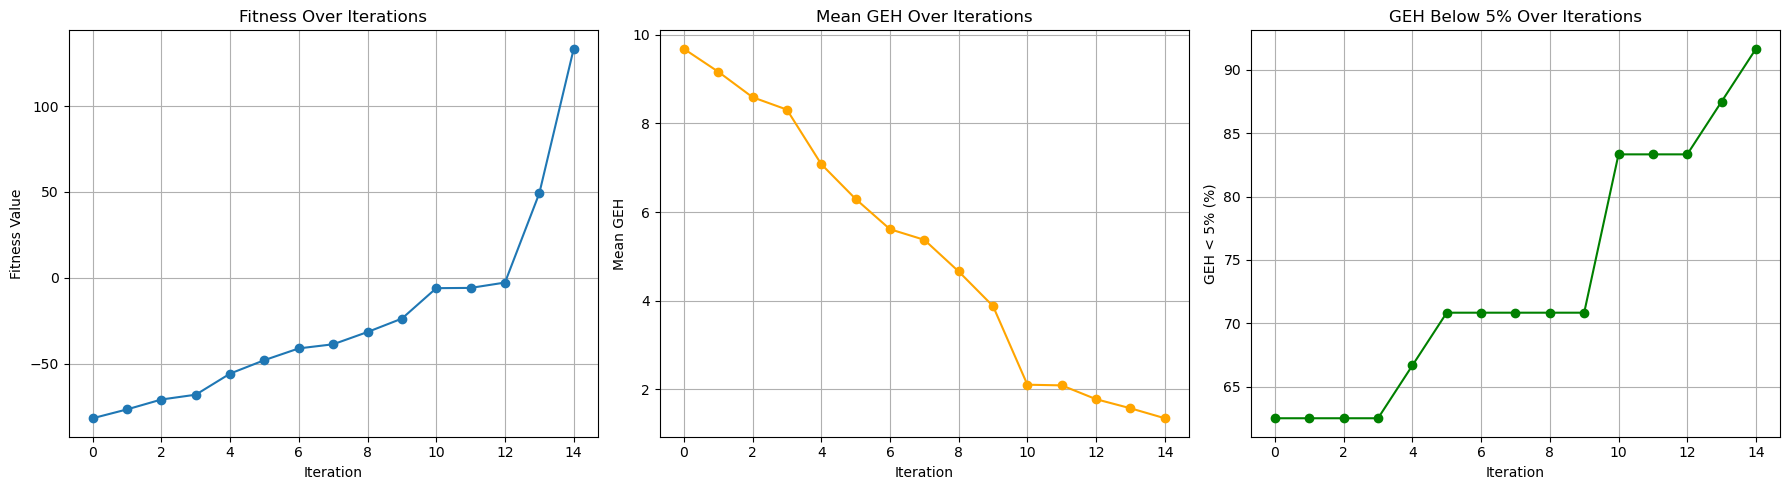

In [24]:
initial_solution = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0, 0, 0, 0]

# Run the Tabu Search
best_solution, best_fitness, fitness_history, mean_geh_history, geh_below_5_percent_history = tabu_search(
    initial_solution, max_iterations, tabu_tenure, neighbor_count)

print(f"\nBest Solution: {best_solution}")
print(f"Best Fitness: {best_fitness:.5f}")

# Plotting the results
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(fitness_history, marker='o')
plt.title("Fitness Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Fitness Value")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(mean_geh_history, marker='o', color='orange')
plt.title("Mean GEH Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Mean GEH")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(geh_below_5_percent_history, marker='o', color='green')
plt.title("GEH Below 5% Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("GEH < 5% (%)")
plt.grid(True)

plt.tight_layout()
plt.show()



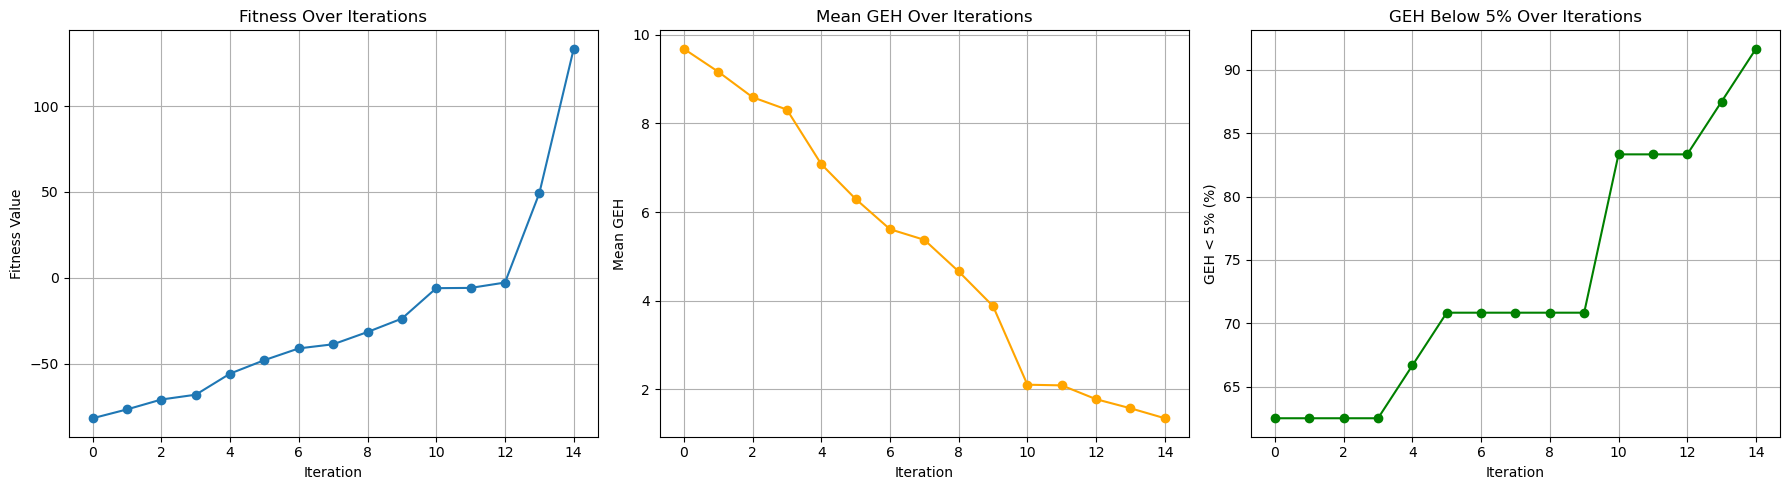

In [25]:
# fitness_history.append(best_fitness)
# mean_geh_history.append(1.4239448988828505)
# geh_below_5_percent_history.append(91.66666666666666)

# Plotting the results
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(fitness_history, marker='o')
plt.title("Fitness Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Fitness Value")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(mean_geh_history, marker='o', color='orange')
plt.title("Mean GEH Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Mean GEH")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(geh_below_5_percent_history, marker='o', color='green')
plt.title("GEH Below 5% Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("GEH < 5% (%)")
plt.grid(True)

plt.tight_layout()
plt.show()



In [26]:
# Find the index of the best fitness within the fitness history
best_index = fitness_history.index(best_fitness)

# Retrieve the corresponding mean GEH and % GEH < 5 at the best index
best_mean_geh = mean_geh_history[best_index]
best_geh_below_5_percent = geh_below_5_percent_history [best_index]

# Print the corresponding values for the best solution
print(f"\nOverall Best Solution: {best_fitness}")
print(f"Overall Best Fitness: {best_fitness:.5f}")
print(f"Mean GEH for Best Solution: {best_mean_geh:.5f}")
print(f"% GEH < 5 for Best Solution: {best_geh_below_5_percent:.2f}%")



Overall Best Solution: 133.33333333333314
Overall Best Fitness: 133.33333
Mean GEH for Best Solution: 1.35090
% GEH < 5 for Best Solution: 91.67%


In [46]:


def set_calibrated_turns(solution,new_file_path):
    global vissim_run_count, vissim_run_times
    """Fitness function for the genetic algorithm."""
    observed_data = get_approach_observed_counts_dictionary_available_intersections(df_gridsmart_demand, '8:00','8:45' )

    resolution = 10  # Set your desired simulation resolution (e.g., 1, 2, 5, 10 steps per second)
    Vissim.Simulation.SetAttValue("SimRes", resolution)


    vissim_seed = 21  # You can change this seed value if needed
    Vissim.Simulation.SetAttValue("RandSeed", vissim_seed)

    turn_ratios = solution[:12]
    vehicle_inputs = solution[12:]
    
    # Measure the time taken for one VISSIM run
    start_vissim_time = time.time()
    
    # Update turn ratios  VISSIM (replace with your logic)
    set_new_route_percent_AminEB(turn_ratios)
    set_new_route_percent_AminWB(turn_ratios)
    set_new_route_percent_Driveway1NB(turn_ratios)
    set_new_route_percent_NapierEB(turn_ratios)
    set_new_route_percent_NapierWB(turn_ratios)
    set_new_route_percent_Driveway2NB(turn_ratios)
    set_new_route_percent_Driveway3NB(turn_ratios)
    set_new_route_percent_LifestyleEB(turn_ratios)
    set_new_route_percent_LifestyleWB(turn_ratios)
    set_new_route_percent_Driveway4SB(turn_ratios)

    # Update vehicle inputs in VISSIM
    update_volumes(vehicle_inputs)
    
    # Run simulation
    Vissim.Simulation.RunContinuous()


    simulation_runs = Vissim.Simulation.AttValue("NumRuns")
    print ("simulation_num_runs", simulation_runs)
    Vissim.SaveNetAs(new_file_path)


    end_vissim_time = time.time()
    vissim_run_duration = end_vissim_time - start_vissim_time
    vissim_run_times.append(vissim_run_duration)
    vissim_run_count += 1
    
    # Collect simulated data from data collection measurements
    simulated_data = get_simulated_count_dictionary(1)
    
    ## Calculate GEH for all data collection points using the dictionaries
    geh_values = calculate_geh_dict(observed_data, simulated_data)
    print (geh_values)
    mean_geh = np.mean([np.mean(geh_list) for geh_list in geh_values.values()])

    print ("mean_gen", (mean_geh))

    # Calculate percentage of GEH values below 5%
    geh_below_5_percent = (np.sum([np.sum(np.array(geh_list) < 5) for geh_list in geh_values.values()]) /
                        np.sum([len(geh_list) for geh_list in geh_values.values()])) * 100
    print ("geh_below_5_percent", geh_below_5_percent)


In [47]:
best_solution =  [0.12, 0.08, 0.06, 0.25, 0.05, 0.04, 0.02, 0.29, 0.5, 0.5, 0.5, 0.5, 0, 190, 155, 190]
new_file_path = r"C:\Users\ets\ORNL Dropbox\Abhilasha Saroj\VSI_Projects\Projects Folder\CC_RealTwin\Preliminary Calibration\VISSIM_Calibration\shallowford\calibrated_turns_vissim_TS.inpx"

In [48]:
set_calibrated_turns(best_solution, new_file_path)

simulation_num_runs 1
{'Amin Dr./Shallowford Village Dr. & Shallowford Rd.': [0.0, 9.620459714409293, 0.0, 0.0], 'Shallowford Rd. & I-75 SB Off Ramp': [1.805034564692788, 1.1593677284194779, 0.0, 0], 'Hamilton Place Blvd./Napier Dr. & Shallowford Rd.': [7.715184315890076, 0.2849614140875866, 0.0, 0.0], 'Lifestyle Way & Shallowford Rd.': [1.3045285561445539, 1.146786116538568, 0.0, 0.0], 'Gunbarrel Road & Shallowford Rd.': [4.8163043039860325, 0.0, 0.052450277757737605, 0.0], 'I-75 NB Off Ramp & Shallowford Rd.': [1.2, 3.207927864984439, 0, 0.10857172400509311]}
mean_gen 1.3508990242048184
geh_below_5_percent 91.66666666666666


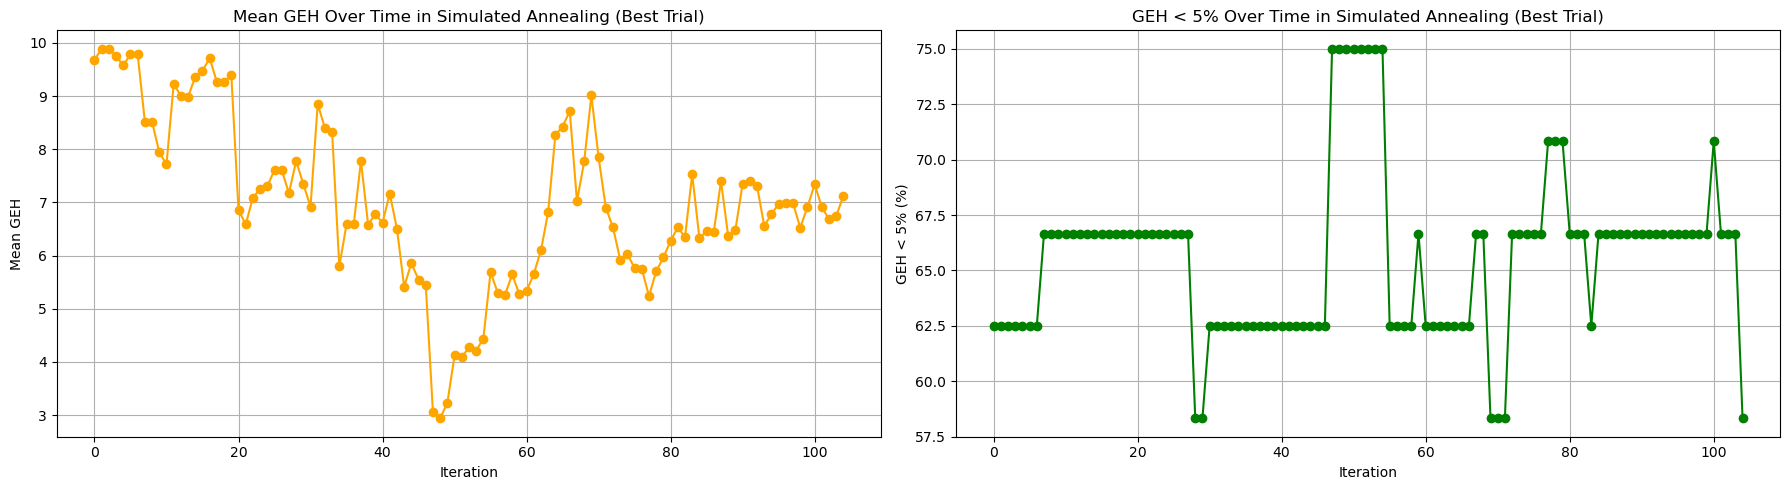

In [43]:
# Plotting the results
plt.figure(figsize=(18, 5))

# Plot fitness values
# plt.subplot(1, 2, 1)
# plt.plot(overall_fitness_history, marker='o')
# plt.title("Fitness Over Time in Simulated Annealing (Best Trial)")
# plt.xlabel("Iteration")
# plt.ylabel("Fitness Value")
# plt.grid(True)

# Plot mean GEH values
plt.subplot(1, 2, 1)
plt.plot(overall_mean_geh_history, marker='o', color='orange')
plt.title("Mean GEH Over Time in Simulated Annealing (Best Trial)")
plt.xlabel("Iteration")
plt.ylabel("Mean GEH")
plt.grid(True)

# Plot GEH below 5% values
plt.subplot(1, 2, 2)
plt.plot(overall_geh_below_5_percent_history, marker='o', color='green')
plt.title("GEH < 5% Over Time in Simulated Annealing (Best Trial)")
plt.xlabel("Iteration")
plt.ylabel("GEH < 5% (%)")
plt.grid(True)

plt.tight_layout()
plt.show()


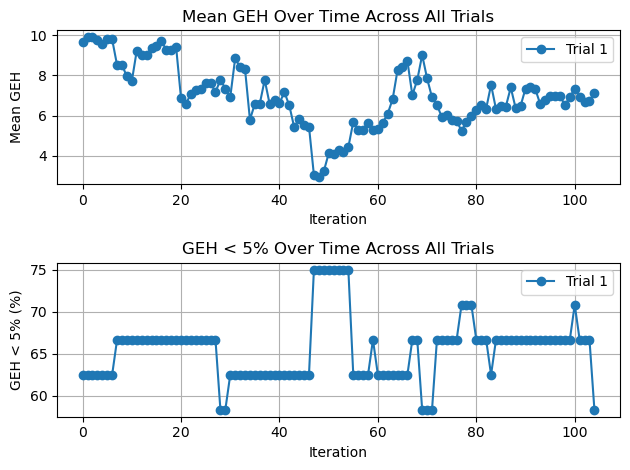

In [40]:
plt.subplot(2, 1, 1)
# for i, fitness_history in enumerate(all_fitness_histories):
#     plt.plot(fitness_history, marker='o', label=f'Trial {i+1}')
# plt.title("Fitness Over Time Across All Trials")
# plt.xlabel("Iteration")
# plt.ylabel("Fitness Value")
# plt.grid(True)
# plt.legend()

# Plot mean GEH values for all trials
plt.subplot(2, 1, 1)
for i, mean_geh_history in enumerate(all_mean_geh_histories):
    plt.plot(mean_geh_history, marker='o', label=f'Trial {i+1}')
plt.title("Mean GEH Over Time Across All Trials")
plt.xlabel("Iteration")
plt.ylabel("Mean GEH")
plt.grid(True)
plt.legend()

# Plot GEH below 5% values for all trials
plt.subplot(2, 1, 2)
for i, geh_below_5_percent_history in enumerate(all_geh_below_5_percent_histories):
    plt.plot(geh_below_5_percent_history, marker='o', label=f'Trial {i+1}')
plt.title("GEH < 5% Over Time Across All Trials")
plt.xlabel("Iteration")
plt.ylabel("GEH < 5% (%)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

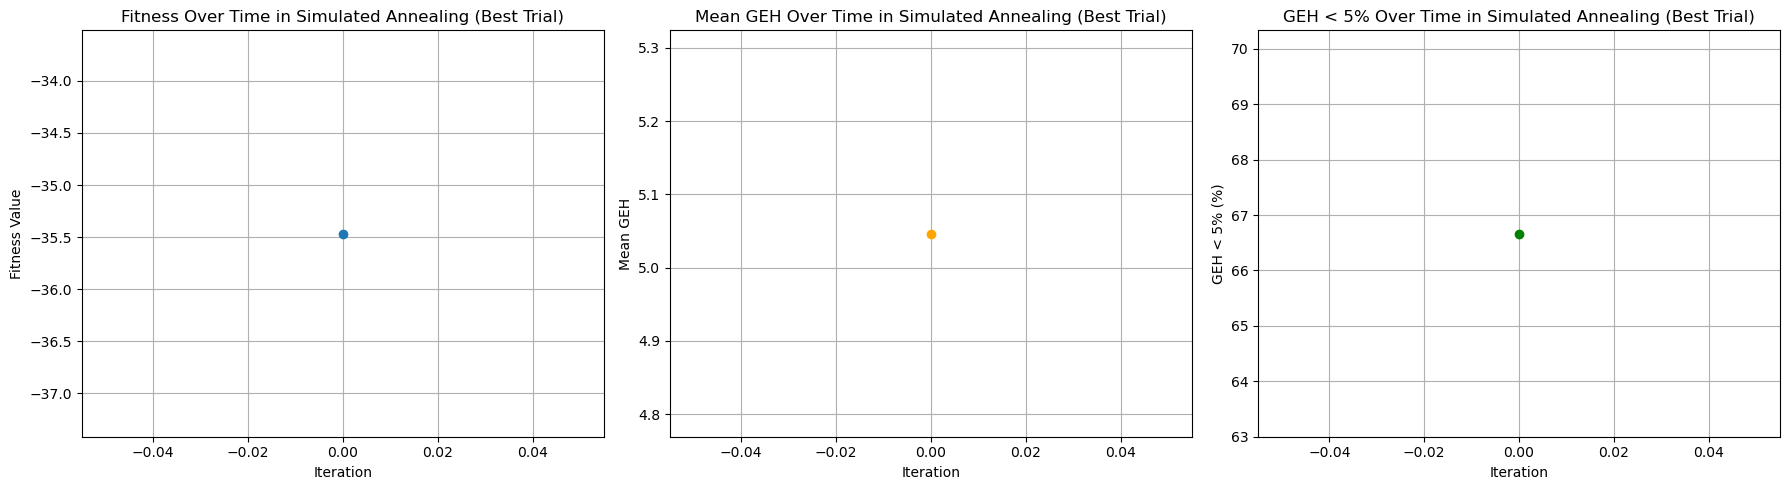

In [24]:
# Plotting the results
plt.figure(figsize=(18, 5))

# Plot fitness values
plt.subplot(1, 3, 1)
plt.plot(overall_fitness_history, marker='o')
plt.title("Fitness Over Time in Simulated Annealing (Best Trial)")
plt.xlabel("Iteration")
plt.ylabel("Fitness Value")
plt.grid(True)

# Plot mean GEH values
plt.subplot(1, 3, 2)
plt.plot(overall_mean_geh_history, marker='o', color='orange')
plt.title("Mean GEH Over Time in Simulated Annealing (Best Trial)")
plt.xlabel("Iteration")
plt.ylabel("Mean GEH")
plt.grid(True)

# Plot GEH below 5% values
plt.subplot(1, 3, 3)
plt.plot(overall_geh_below_5_percent_history, marker='o', color='green')
plt.title("GEH < 5% Over Time in Simulated Annealing (Best Trial)")
plt.xlabel("Iteration")
plt.ylabel("GEH < 5% (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

simulation_num_runs 1
{'Amin Dr./Shallowford Village Dr. & Shallowford Rd.': [0.0, 12.019206996649542, 0.0, 0.0], 'Shallowford Rd. & I-75 SB Off Ramp': [3.279992333116728, 9.746132586446624, 0.0, 0], 'Hamilton Place Blvd./Napier Dr. & Shallowford Rd.': [6.412189417096857, 12.827934164539103, 6.6332495807108, 27.60731093011867], 'Lifestyle Way & Shallowford Rd.': [0.9248582085000898, 18.45434487811587, 10.583737708199735, 11.35455529406264], 'Gunbarrel Road & Shallowford Rd.': [12.53471745704056, 0.8852677897456388, 16.699598670168122, 24.108481580559395], 'I-75 NB Off Ramp & Shallowford Rd.': [16.261256708842946, 9.115097514952463, 26.981475126464083, 14.314807214341252]}
mean_gen 10.03100892331963
geh_below_5_percent 33.33333333333333
initial_fitness -10.03100892331963
simulation_num_runs 1
{'Amin Dr./Shallowford Village Dr. & Shallowford Rd.': [0.0, 11.979080215228608, 0.0, 0.0], 'Shallowford Rd. & I-75 SB Off Ramp': [3.279992333116728, 9.746132586446624, 0.0, 0], 'Hamilton Place Blv

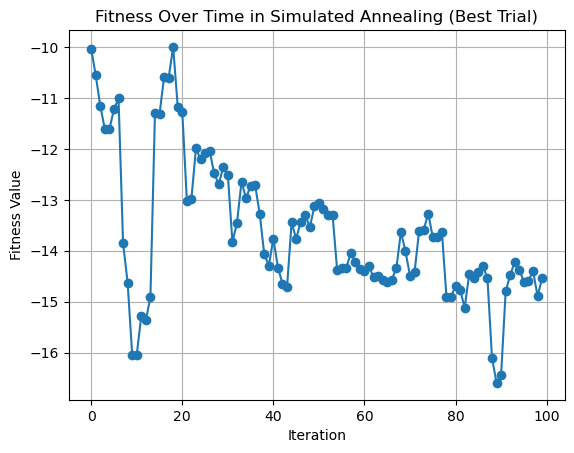

In [57]:
# import random
# import numpy as np
# import matplotlib.pyplot as plt

# # Initialize global variables for VISSIM runs (simulated for this example)
# vissim_run_count = 0
# vissim_run_times = []

# # Simulated Annealing Parameters
# initial_temperature = 1000
# cooling_rate = 0.95  # Slightly faster cooling rate
# min_temperature = 5
# max_iterations = 100  # Increase iterations to allow more exploration
# num_trials = 5  # Number of different initial solutions to try

# # Function to generate a neighboring solution
# def get_neighbor(solution, gene_space):
#     neighbor = solution.copy()
#     gene_idx = random.randint(0, len(solution) - 1)
    
#     if gene_idx < 12:  # Turn ratios
#         neighbor[gene_idx] = random.choice(np.arange(gene_space[gene_idx]['low'], gene_space[gene_idx]['high'] + gene_space[gene_idx]['step'], gene_space[gene_idx]['step']))
#     else:  # Vehicle inputs
#         neighbor[gene_idx] = random.choice(np.arange(gene_space[gene_idx]['low'], gene_space[gene_idx]['high'] + gene_space[gene_idx]['step'], gene_space[gene_idx]['step']))
    
#     return neighbor

# # Function to perform simulated annealing
# def simulated_annealing(initial_solution):
#     current_solution = initial_solution
#     current_fitness = objective_function(current_solution)
#     print ("initial_fitness", current_fitness)
#     best_solution = current_solution
#     best_fitness = current_fitness

#     temperature = initial_temperature
#     fitness_history = [current_fitness]

    
#     while temperature > min_temperature and vissim_run_count < max_iterations:
#         neighbor_solution = get_neighbor(current_solution, gene_space)
#         neighbor_fitness = objective_function(neighbor_solution)
        
#         # Decide whether to move to the neighbor solution
#         if neighbor_fitness > current_fitness or random.uniform(0, 1) < np.exp((neighbor_fitness - current_fitness) / temperature):
#             current_solution = neighbor_solution
#             current_fitness = neighbor_fitness
        
#         # Update the best solution
#         if current_fitness > best_fitness:
#             best_solution = current_solution
#             best_fitness = current_fitness
        
#         fitness_history.append(current_fitness)
        
#         # Cool down
#         temperature *= cooling_rate
    
#     return best_solution, best_fitness, fitness_history

# # Gene space with step changes
# gene_space = [{'low': 0, 'high': 1, 'step': 0.05}] * 12 + [{'low': 200, 'high': 800, 'step': 25}] * 4

# # Running multiple trials with different initial solutions
# all_best_solutions = []
# all_best_fitnesses = []
# all_fitness_histories = []

# for trial in range(num_trials):
#     # Generate a random initial solution for each trial
#     if trial ==0:
#         initial_solution = [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.5, 0.5, 0.5, 0.5, 0, 0, 0, 0]
#     else:
#         initial_solution = [round(random.uniform(g['low'], g['high']) / g['step']) * g['step'] for g in gene_space]
#         print(f"Trial {trial + 1}: Starting with initial solution {initial_solution}")
    
#     best_solution, best_fitness, fitness_history = simulated_annealing(initial_solution)
    
#     all_best_solutions.append(best_solution)
#     all_best_fitnesses.append(best_fitness)
#     all_fitness_histories.append(fitness_history)
    
#     print(f"Trial {trial + 1}: Best Fitness = {best_fitness:.5f}")

# # Determine the overall best solution across all trials
# overall_best_fitness = max(all_best_fitnesses)
# overall_best_solution = all_best_solutions[all_best_fitnesses.index(overall_best_fitness)]
# overall_fitness_history = all_fitness_histories[all_best_fitnesses.index(overall_best_fitness)]

# print(f"\nOverall Best Solution: {overall_best_solution}")
# print(f"Overall Best Fitness: {overall_best_fitness:.5f}")

# # Plotting the fitness over time for the best trial
# plt.plot([round(f, 5) for f in overall_fitness_history], marker='o')
# plt.title("Fitness Over Time in Simulated Annealing (Best Trial)")
# plt.xlabel("Iteration")
# plt.ylabel("Fitness Value")
# plt.grid(True)
# plt.show()

# # Close VISSIM
# Vissim = None



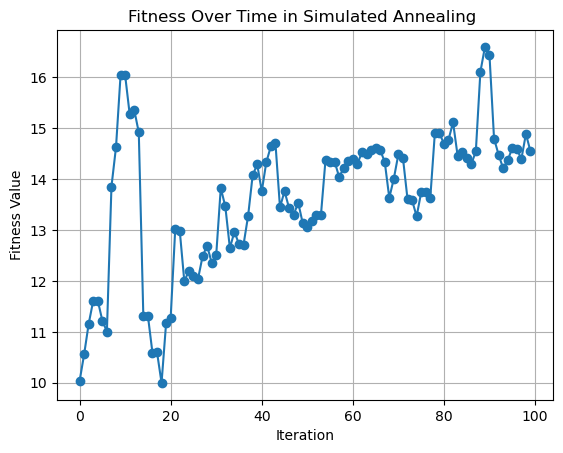

In [58]:
multiplied_list = list(map(lambda x: x * -1, overall_fitness_history))
# Plotting the fitness over time for the best trial
plt.plot([round(f, 5) for f in multiplied_list], marker='o')
plt.title("Fitness Over Time in Simulated Annealing ")
plt.xlabel("Iteration")
plt.ylabel("Fitness Value")
plt.grid(True)
plt.show()

In [33]:
# import random
# # Initialize global variables for VISSIM runs
# vissim_run_count = 0
# vissim_run_times = []

# # Simulated Annealing Parameters
# initial_temperature = 1000
# cooling_rate = 0.9824
# min_temperature = 5
# max_iterations = 100

# # Function to generate a neighboring solution
# def get_neighbor(solution, gene_space):
#     neighbor = solution.copy()
#     gene_idx = random.randint(0, len(solution) - 1)
    
#     if gene_idx < 12:  # Turn ratios
#         neighbor[gene_idx] = random.choice(np.arange(gene_space[gene_idx]['low'], gene_space[gene_idx]['high'] + gene_space[gene_idx]['step'], gene_space[gene_idx]['step']))
#     else:  # Vehicle inputs
#         neighbor[gene_idx] = random.choice(np.arange(gene_space[gene_idx]['low'], gene_space[gene_idx]['high'] + gene_space[gene_idx]['step'], gene_space[gene_idx]['step']))
    
#     return neighbor

# # Initialize the solution (start from the initial solution)
# initial_solution = [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.5, 0.5, 0.5, 0.5, 0, 0, 0, 0]

# # Gene space with step changes
# gene_space = [{'low': 0, 'high': 1, 'step': 0.01}] * 12 + [{'low': 200, 'high': 800, 'step': 50}] * 4

# # Simulated Annealing Implementation
# current_solution = initial_solution
# current_fitness = objective_function(current_solution)
# print (current_solution, current_fitness)
# best_solution = current_solution
# best_fitness = current_fitness

# temperature = initial_temperature
# fitness_history = [current_fitness]
# i = 0
# while temperature > min_temperature and vissim_run_count < max_iterations:
#     print ("Iternation No", i)
#     i = i+1
#     neighbor_solution = get_neighbor(current_solution, gene_space)
#     print ("neighbor solution", neighbor_solution)
#     neighbor_fitness = objective_function(neighbor_solution)
    
#     # Decide whether to move to the neighbor solution
#     if neighbor_fitness > current_fitness or random.uniform(0, 1) < np.exp((neighbor_fitness - current_fitness) / temperature):
#         current_solution = neighbor_solution
#         current_fitness = neighbor_fitness
    
#     # Update the best solution
#     if current_fitness > best_fitness:
#         best_solution = current_solution
#         best_fitness = current_fitness
    
#     fitness_history.append(current_fitness)
    
#     # Cool down
#     temperature *= cooling_rate

# # Results
# print(f"Best Solution: {best_solution}")
# print(f"Best Solution Fitness: {best_fitness}")

# # Plotting the fitness over time
# plt.plot(fitness_history, marker='o')
# plt.title("Fitness Over Time in Simulated Annealing")
# plt.xlabel("Iteration")
# plt.ylabel("Fitness Value")
# plt.grid(True)
# plt.show()

# # Close VISSIM
# Vissim = None


{'Amin Dr./Shallowford Village Dr. & Shallowford Rd.': [0.08147069510681637, 13.66240047451015, 0.037307152949332796, 0.02306737766987931], 'Shallowford Rd. & I-75 SB Off Ramp': [4.779664452745376, 11.972125075457242, 0.08618478840809106, 0], 'Hamilton Place Blvd./Napier Dr. & Shallowford Rd.': [7.572103998399644, 14.903846107370306, 6.6332495807108, 27.54810501670109], 'Lifestyle Way & Shallowford Rd.': [0.6807530500820339, 17.57681294859221, 10.595782690957085, 11.317027702736542], 'Gunbarrel Road & Shallowford Rd.': [16.627224097220616, 1.726816202537844, 16.728800860674742, 24.122423453905483], 'I-75 NB Off Ramp & Shallowford Rd.': [18.57332066194042, 9.217130082658995, 26.891416940814885, 14.37813182319338]}
mean_gen 10.655631884805958
geh_below_5_percent 33.33333333333333
Iternation No 0
neighbor solution [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.5, 0.5, 0.5, 0.5, 0, 2000, 0, 0]
{'Amin Dr./Shallowford Village Dr. & Shallowford Rd.': [0.08141314908119193, 13.660029694534789, 0.03

com_error: (-2147352567, 'Exception occurred.', (0, None, None, None, 0, -2147467259), None)

In [31]:
print (fitness_history)

[-10.480711426516107, -10.48149387733522, -10.482274736268467, -10.482878468950643, -10.483480999828776, -10.485087002495577, -10.486773535125424, -10.490198255657871, -10.492169820195377, -10.494137869863813, -10.494545808226627, -10.495516404261204, -10.49698143069986, -10.497683552881496, -10.498384570227223, -10.499352454519004, -10.50087238304298, -10.502218055270166, -10.504088101017693, -10.505836827542483, -10.506727554134978, -10.507872873283139, -10.509056598779752, -10.510238412960538, -10.509276748431947, -10.508769610429546, -10.50812799571022, -10.507532442135709, -10.506951215815915, -10.506919382775928, -10.506867086010702, -10.506880776658713, -10.506849986934098, -10.506664705820809, -10.507674303887166, -10.50988886109564, -10.511868904348534, -10.514521952990359, -10.517170602776355, -10.519603886654526, -10.522047335510905, -10.524486731176745, -10.527317764043097, -10.529683660139684, -10.531574483558755, -10.533570026200325, -10.535329535749314, -10.5373336443646

In [25]:
# # Define the initial solution
# initial_solution = [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.5, 0.5, 0.5, 0.5, 0, 0, 0, 0]


# # Create a fixed initial population by replicating the initial solution
# population_size = 10  # Number of solutions in the initial population
# initial_population = np.tile(initial_solution, (population_size, 1)) + np.random.uniform(0, 0.05, (population_size, len(initial_solution)))
# # initial_population = np.tile(initial_solution, (population_size, 1))

# # Measure the start time
# start_time = time.time()

# # To store the best fitness values over generations
# best_fitness_values = []

# # Set up the PyGAD genetic algorithm
# ga_instance = pygad.GA(
#     num_generations=20,  # More generations for better convergence
#     num_parents_mating=4,  # More parents to maintain genetic diversity
#     fitness_func=objective_function,
#     sol_per_pop=population_size,  # Matches the initial population size
#     num_genes=16,  # The number of genes in the initial solution
#     gene_space=[{'low': 0, 'high': 1, 'step': 0.001}] * 12 + [{'low': 400, 'high': 1600, 'step': 50}] * 4,  # Define gene space for the search
#     mutation_percent_genes=10,  # Lower mutation rate for more focused optimization
#     mutation_type="random",
#     crossover_type="two_points",
#     keep_elitism=2, 
#     initial_population=initial_population,  # Set the initial population
#     on_generation=lambda ga_instance: best_fitness_values.append(ga_instance.best_solution()[1])
#     )

# # Run the GA to optimize VISSIM parameters
# ga_instance.run()

# # Measure the end time
# end_time = time.time()

# # Calculate the elapsed time
# elapsed_time = end_time - start_time
# print(f"Time taken for GA instance run: {elapsed_time:.2f} seconds")

# # Output the total number of VISSIM runs and average time per run
# print(f"Total number of VISSIM runs: {vissim_run_count}")
# if vissim_run_count > 0:
#     average_vissim_time = sum(vissim_run_times) / vissim_run_count
#     print(f"Average time per VISSIM run: {average_vissim_time:.2f} seconds")
    
# # Get the best solution
# best_solution, best_solution_fitness, best_solution_idx = ga_instance.best_solution()
# # Format the best solution values to 4 decimal places
# best_solution_formatted = [f"{value:.4f}" for value in best_solution]

# print(f"Best Solution: {best_solution_formatted}")
# print(f"Best Solution Fitness: {best_solution_fitness}")  # Fitness is %GEH < 5% minus mean GEH


# # Calculate final GEH and %GEH < 5% for the best solution
# turn_ratios = best_solution[:12]
# vehicle_inputs = best_solution[12:]


# # Update turn ratios  VISSIM (replace with your logic)
# set_new_route_percent_AminEB(turn_ratios)
# set_new_route_percent_AminWB(turn_ratios)
# set_new_route_percent_Driveway1NB(turn_ratios)
# set_new_route_percent_NapierEB(turn_ratios)
# set_new_route_percent_NapierWB(turn_ratios)
# set_new_route_percent_Driveway2NB(turn_ratios)
# set_new_route_percent_Driveway3NB(turn_ratios)
# set_new_route_percent_LifestyleEB(turn_ratios)
# set_new_route_percent_LifestyleWB(turn_ratios)
# set_new_route_percent_Driveway4SB(turn_ratios)

# # Update vehicle inputs in VISSIM
# update_volumes(vehicle_inputs)

# # Run simulation
# Vissim.Simulation.RunContinuous()

# observed_data = get_approach_observed_counts_dictionary_available_intersections(df_gridsmart_demand, '8:00','8:45' )
# # Collect simulated data from data collection measurements
# simulated_data = get_simulated_count_dictionary()

# # Calculate GEH for all data collection points using the dictionaries
# geh_values = calculate_geh_dict(observed_data, simulated_data)
# mean_geh = np.mean([np.mean(geh_list) for geh_list in geh_values.values()])

# # Calculate percentage of GEH values below 5%
# geh_below_5_percent = (np.sum([np.sum(np.array(geh_list) < 5) for geh_list in geh_values.values()]) /
#                        np.sum([len(geh_list) for geh_list in geh_values.values()])) * 100

# # Output results
# print(f"Final Mean GEH: {mean_geh}")
# print(f"Final %GEH below 5%: {geh_below_5_percent}%")

# # Plot the best fitness values over generations
# plt.plot(best_fitness_values, marker='o')
# plt.title("Best Fitness Value Over Generations")
# plt.xlabel("Generation")
# plt.ylabel("Best Fitness Value")
# plt.grid(True)
# plt.show()

# # Close VISSIM
# Vissim = None



Undefined crossover type. 
The assigned value to the crossover_type (two_point) parameter does not refer to one of the supported crossover types which are: 
-single_point (for single point crossover)
-two_points (for two points crossover)
-uniform (for uniform crossover)
-scattered (for scattered crossover).
Traceback (most recent call last):
  File "c:\Users\ets\Anaconda3\lib\site-packages\pygad\pygad.py", line 612, in __init__
    raise TypeError(f"Undefined crossover type. \nThe assigned value to the crossover_type ({crossover_type}) parameter does not refer to one of the supported crossover types which are: \n-single_point (for single point crossover)\n-two_points (for two points crossover)\n-uniform (for uniform crossover)\n-scattered (for scattered crossover).\n")
TypeError: Undefined crossover type. 
The assigned value to the crossover_type (two_point) parameter does not refer to one of the supported crossover types which are: 
-single_point (for single point crossover)
-two_poi

TypeError: Undefined crossover type. 
The assigned value to the crossover_type (two_point) parameter does not refer to one of the supported crossover types which are: 
-single_point (for single point crossover)
-two_points (for two points crossover)
-uniform (for uniform crossover)
-scattered (for scattered crossover).


In [ ]:


# Run the genetic algorithm - Saturday
ga_instance.run()

# Get the best solution
best_solution, best_solution_fitness, best_solution_idx = ga_instance.best_solution()
print(f"Best Solution: {best_solution}, Fitness: {best_solution_fitness}")

# Apply the best solution to Vissim (if applicable)

# Save the calibrated network
Vissim.SaveNet(r"Path\To\Save\Calibrated\Network.inpx")

# Close Vissim
Vissim = None

In [ ]:
turn_ratios = solution[:12]
vehicle_inputs = solution[12:]

# Measure the time taken for one VISSIM run
start_vissim_time = time.time()

# Update turn ratios  VISSIM (replace with your logic)
set_new_route_percent_AminEB(turn_ratios)
set_new_route_percent_AminWB(turn_ratios)
set_new_route_percent_Driveway1NB(turn_ratios)
set_new_route_percent_NapierEB(turn_ratios)
set_new_route_percent_NapierWB(turn_ratios)
set_new_route_percent_Driveway2NB(turn_ratios)
set_new_route_percent_Driveway3NB(turn_ratios)
set_new_route_percent_LifestyleEB(turn_ratios)
set_new_route_percent_LifestyleWB(turn_ratios)
set_new_route_percent_Driveway4SB(turn_ratios)

# Update vehicle inputs in VISSIM
update_volumes(vehicle_inputs)

# Run simulation
Vissim.Simulation.RunContinuous()